# 1.1 Linear Models（線形モデル）

原典: https://scikit-learn.org/stable/modules/linear_model.html （v1.9.1）

> 表記: 「原典」= ガイドの記述の日本語化 / 「確認」= 自分で実行して確かめたこと / 「発見」= ガイドに書かれておらず実行で分かったこと

## セットアップ

このノートブックは**実行済みの出力つき**で保存している。GitHub 上でそのまま読める。手元で再実行する場合は `pip install -r requirements.txt`（scikit-learn 1.9.1）のうえで先頭から順に実行する（乱数を共有しているため、途中のセルだけ再実行すると数値が変わる）。

In [1]:
import warnings

import numpy as np
from scipy.special import expit
from sklearn import linear_model as lm
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline

np.set_printoptions(precision=4, suppress=True)
rng = np.random.RandomState(0)


def h(title):
    print(f"\n=== {title} ===")


# ---------------------------------------------------------------- 1.1.1 OLS

import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (5.6, 3.4), "figure.dpi": 80, "axes.grid": True})
warnings.filterwarnings("ignore", message=".*sklearn.utils.parallel.delayed.*")


## 全体像（アナロジー）

**線形モデル = 「各特徴に重み（つまみ）を付けて足し合わせるミキサー」**。つまみ `coef_` と、ベースライン `intercept_` を学習する。

- 何を最小化するか（損失）と、つまみをどれだけ絞るか（正則化）の組み合わせで、手法が分かれる。
- OLS → Ridge → Lasso → ElasticNet は「つまみの絞り方」の違い。
- ロジスティック回帰・GLM は「ミキサーの出力を、どんな確率分布・リンク関数で解釈するか」の違い。

原典の定義: 予測値 `ŷ(w, x) = w₀ + w₁x₁ + … + wₚxₚ`。`w = (w₁…wₚ)` を **`coef_`**、`w₀` を **`intercept_`** と呼ぶ（モジュール全体で共通）。

| 手法 | 損失＋ペナルティ | 一言 |
|------|------------------|------|
| OLS | 二乗誤差のみ | 素直。共線性に弱い |
| Ridge | + α‖w‖₂² | 係数を全体に縮める |
| Lasso | + α‖w‖₁ | 係数を **厳密に 0** にする（スパース） |
| ElasticNet | + L1 と L2 の凸結合 | 相関の強い特徴をまとめて選ぶ |
| Bayesian / ARD | 正則化の強さもデータから推定 | αを自動調整 |
| Logistic | 対数損失 | 分類（回帰ではない） |
| GLM | 単位逸脱度 + L2 | 分布とリンクを選べる |
| Huber / RANSAC / Theil-Sen | 外れ値に頑健 | |
| Quantile | ピンボール損失 | 中央値や分位点を予測 |

## 1.1.1 Ordinary Least Squares（最小二乗法）

**原典**: `LinearRegression` は残差平方和 `min‖Xw − y‖²` を最小化する。`fit(X, y, sample_weight)` を受け取り、`coef_` と `intercept_` に保存する。特徴が独立であることに係数推定が依存し、列がほぼ線形従属（**多重共線性**）だと、目的変数の小さなノイズに推定が非常に敏感（分散が大）になる。

In [2]:
h("1.1.1 OLS: ガイドの例")
reg = lm.LinearRegression().fit([[0, 0], [1, 1], [2, 2]], [0, 1, 2])
print("coef_", reg.coef_, "intercept_", reg.intercept_)
# 特徴が完全共線 (x1 == x2) なので、係数は 0.5/0.5 (最小ノルム解) に定まる
assert np.allclose(reg.coef_, [0.5, 0.5])


=== 1.1.1 OLS: ガイドの例 ===
coef_ [0.5 0.5] intercept_ 1.1102230246251565e-16


In [3]:
h("1.1.1 多重共線性: 特徴がほぼ同一のとき、係数がノイズに敏感になる")
n = 50
x1 = rng.randn(n)
for eps in [1.0, 0.01, 0.0001]:
    x2 = x1 + eps * rng.randn(n)  # eps が小さいほど x1 とほぼ同じ
    X = np.c_[x1, x2]
    coefs = []
    for seed in range(200):
        y = x1 + np.random.RandomState(seed).randn(n) * 0.5  # 真の係数は (1, 0)
        coefs.append(lm.LinearRegression().fit(X, y).coef_)
    print(f"x2=x1+{eps:<6} coef[0] の標準偏差 {np.std(np.array(coefs)[:, 0]):.3f}")


=== 1.1.1 多重共線性: 特徴がほぼ同一のとき、係数がノイズに敏感になる ===
x2=x1+1.0    coef[0] の標準偏差 0.105


x2=x1+0.01   coef[0] の標準偏差 7.036
x2=x1+0.0001 coef[0] の標準偏差 718.905


**動かして確認**
- 完全共線でも解は定まる（最小ノルム解 `0.5, 0.5`）。ただし真の意味で一意なわけではない。
- 多重共線性の影響を、200 回ノイズを変えて `coef[0]` の標準偏差で測った（真の係数は (1, 0)）:

| x2 = x1 + ノイズ | coef[0] の標準偏差 |
|---|---|
| ノイズ 1.0 | 0.105 |
| ノイズ 0.01 | 7.036 |
| ノイズ 0.0001 | **718.905** |

→ 特徴が似るほど、係数は数千倍ぶれる。**予測は安定していても係数の解釈は危うい**。

### 1.1.1.1 Non-Negative Least Squares
**原典**: `positive=True` で係数を非負に制限できる（頻度や価格など、物理的に非負な量）。

In [4]:
h("1.1.1.1 Non-negative least squares (positive=True)")
X = rng.randn(100, 3)
y = X @ [2.0, -1.0, 0.5] + 0.1 * rng.randn(100)
print("通常     :", lm.LinearRegression().fit(X, y).coef_)
print("positive :", lm.LinearRegression(positive=True).fit(X, y).coef_)
assert (lm.LinearRegression(positive=True).fit(X, y).coef_ >= 0).all()


=== 1.1.1.1 Non-negative least squares (positive=True) ===
通常     : [ 1.9849 -0.9844  0.5041]
positive : [2.0859 0.     0.5945]


**確認**: 真の係数 `[2, -1, 0.5]` のデータで、通常は `[1.98, -0.98, 0.50]`、`positive=True` は `[2.09, 0, 0.59]`。負だった係数は 0 に張り付き、**他の係数もそれに引きずられて変わる**。

### 1.1.1.2 計算量
**原典**: SVD で解く。`O(n_samples · n_features²)`（`n_samples ≥ n_features` の場合）。

## 1.1.2 Ridge 回帰と分類

### 1.1.2.1 回帰
**原典**: 係数の大きさにペナルティを課して OLS の問題を和らげる。`min‖Xw−y‖² + α‖w‖₂²`。α が大きいほど縮小が強く、共線性に頑健になる。`solver="auto"` の選択は上から順に判定: ①`positive=True` なら `lbfgs`、②X が疎でなければ `cholesky`、③それ以外は `sparse_cg`。

In [5]:
h("1.1.2.1 Ridge: ガイドの例")
reg = lm.Ridge(alpha=0.5).fit([[0, 0], [0, 0], [1, 1]], [0, 0.1, 1])
print("coef_", reg.coef_, "intercept_", reg.intercept_)
assert np.allclose(reg.coef_, [0.34545455] * 2) and np.isclose(reg.intercept_, 0.13636, atol=1e-5)


=== 1.1.2.1 Ridge: ガイドの例 ===
coef_ [0.3455 0.3455] intercept_ 0.13636363636363638


In [6]:
h("1.1.2.1 alpha を大きくすると係数が縮む (shrinkage)")
X = rng.randn(60, 5)
y = X @ [3, -2, 1, 0, 0] + rng.randn(60)
for a in [0, 1, 10, 100, 1000]:
    print(f"alpha={a:<5}", "||w||2 =", round(float(np.linalg.norm(lm.Ridge(alpha=a).fit(X, y).coef_)), 3))


=== 1.1.2.1 alpha を大きくすると係数が縮む (shrinkage) ===
alpha=0     ||w||2 = 4.015
alpha=1     ||w||2 = 3.953
alpha=10    ||w||2 = 3.476
alpha=100   ||w||2 = 1.623
alpha=1000  ||w||2 = 0.261


In [7]:
h("1.1.2.1 solver='auto' の選択規則 (positive=True -> lbfgs)")
print("dense:", lm.Ridge().fit(X, y).coef_[:2], "/ positive=True:", lm.Ridge(positive=True).fit(X, y).coef_[:2])


=== 1.1.2.1 solver='auto' の選択規則 (positive=True -> lbfgs) ===
dense: [ 3.166  -1.8215] / positive=True: [3.1854 0.    ]


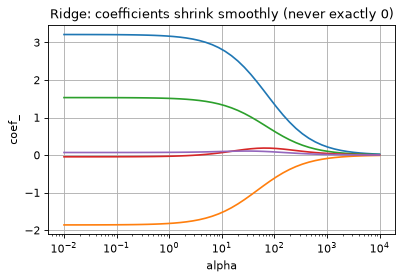

In [8]:
alphas = np.logspace(-2, 4, 50)
coefs = [lm.Ridge(alpha=a).fit(X, y).coef_ for a in alphas]
plt.semilogx(alphas, coefs); plt.xlabel("alpha"); plt.ylabel("coef_")
plt.title("Ridge: coefficients shrink smoothly (never exactly 0)"); plt.show()

**確認**
α を上げるほど係数のノルムが単調に縮む。`positive=True` は非負制約付きで別ソルバ（lbfgs）に切り替わる。

### 1.1.2.2 分類（RidgeClassifier）
**原典**: 二値の目的変数を `{-1, 1}` に変換して回帰問題として解き、予測の**符号**でクラスを決める。多クラスは多出力回帰として扱い、最大値の出力がクラス。二乗損失で分類するのは奇妙に見えるが、CV スコアは他の損失とほぼ同じになり得て、ソルバの選択肢と性能特性が変わる。クラス数が多いとき `LogisticRegression` より速い（射影行列 `(XᵀX)⁻¹Xᵀ` を 1 回だけ計算できる）。

In [9]:
h("1.1.2.2 RidgeClassifier: 二値目的変数を {-1,1} に直して回帰、符号で分類")
Xc = np.r_[rng.randn(30, 2) + [2, 2], rng.randn(30, 2) - [2, 2]]
yc = np.r_[np.ones(30, int), np.zeros(30, int)]
rc = lm.RidgeClassifier().fit(Xc, yc)
pred_by_sign = (rc.decision_function(Xc) > 0).astype(int)
print("classes_", rc.classes_, "| predict == 符号判定:", (rc.predict(Xc) == pred_by_sign).all())
ridge_pm = lm.Ridge().fit(Xc, 2 * yc - 1)  # 手で {-1,1} にして Ridge
print("二値の coef_ の形: RidgeClassifier", rc.coef_.shape, "/ LogisticRegression", lm.LogisticRegression().fit(Xc, yc).coef_.shape)
print("Ridge(±1) の係数・decision_function と一致:", np.allclose(ridge_pm.coef_, rc.coef_), np.allclose(ridge_pm.predict(Xc), rc.decision_function(Xc)))


=== 1.1.2.2 RidgeClassifier: 二値目的変数を {-1,1} に直して回帰、符号で分類 ===
classes_ [0 1] | predict == 符号判定: True
二値の coef_ の形: RidgeClassifier (2,) / LogisticRegression (1, 2)
Ridge(±1) の係数・decision_function と一致: True True


**確認**
- `Ridge` に手で `{-1, 1}` を与えた結果と、`RidgeClassifier` の `coef_` / `decision_function` が**完全一致**した。「符号で判定」という説明どおり。
- **発見**: 二値のとき `RidgeClassifier.coef_` の形は `(2,)`（1 次元）。`LogisticRegression.coef_` は `(1, 2)`。**同じ分類器でも `coef_` の形が揃っていない**ので、差し替えるコードは `np.ravel` などで吸収が要る。

### 1.1.2.3 計算量
OLS と同じオーダー。

### 1.1.2.4 正則化パラメータの選択: LOO-CV
**原典**: `RidgeCV` / `RidgeClassifierCV` は α を組み込み交差検証で選ぶ。`GridSearchCV` と同様に動くが、既定は効率的な **Leave-One-Out**。既定の CV では **α は 0 にできない**（LOO 誤差の計算式の都合）。`cv=10` のように指定すると `GridSearchCV` で K 分割 CV になる。

In [10]:
h("1.1.2.4 RidgeCV: ガイドの例 (既定は LOO-CV)")
reg = lm.RidgeCV(alphas=np.logspace(-6, 6, 13)).fit([[0, 0], [0, 0.1], [1, 1]], [0, -0.1, 1])
print("alpha_", reg.alpha_)
assert np.isclose(reg.alpha_, 0.1)
try:
    lm.RidgeCV(alphas=[0.0, 1.0]).fit(X, y)
except ValueError as e:
    print("alpha=0 + LOO ->", type(e).__name__, str(e)[:70])


=== 1.1.2.4 RidgeCV: ガイドの例 (既定は LOO-CV) ===
alpha_ 0.1
alpha=0 + LOO -> ValueError alphas[0] == 0.0, must be > 0.0.


**確認**: ガイドの例で `alpha_ = 0.1`。`alphas=[0.0, 1.0]` を渡すと `ValueError: alphas[0] == 0.0, must be > 0.0.`。

## 1.1.3 Lasso

**原典**: **係数を厳密に 0 にできる**スパースな線形モデル。使う特徴が少ない解を好むので、事実上の特徴選択になる（圧縮センシングの基礎）。目的関数は `1/(2n)·‖Xw−y‖² + α‖w‖₁`。`Lasso` は座標降下法で解く（LARS による別実装は 1.1.7）。`lasso_path` で正則化パス全体を低レベルで得られる。

In [11]:
h("1.1.3 Lasso: ガイドの例と、係数が厳密に 0 になること")
reg = lm.Lasso(alpha=0.1).fit([[0, 0], [1, 1]], [0, 1])
print("predict([[1,1]]) =", reg.predict([[1, 1]]))
assert np.allclose(reg.predict([[1, 1]]), [0.8])
X = rng.randn(100, 10)
y = X[:, 0] * 3 - X[:, 1] * 2 + 0.5 * rng.randn(100)
for name, m in [("Ridge", lm.Ridge(alpha=10)), ("Lasso", lm.Lasso(alpha=0.3))]:
    c = m.fit(X, y).coef_
    print(f"{name:6} 厳密な0の個数 = {(c == 0).sum()} / 10   coef = {c}")


=== 1.1.3 Lasso: ガイドの例と、係数が厳密に 0 になること ===
predict([[1,1]]) = [0.8]
Ridge  厳密な0の個数 = 0 / 10   coef = [ 2.7773 -1.8132  0.0205  0.0073 -0.0212  0.0116  0.1065  0.0485  0.0455
 -0.0022]
Lasso  厳密な0の個数 = 8 / 10   coef = [ 2.7855 -1.7019  0.     -0.     -0.     -0.      0.      0.      0.
 -0.    ]


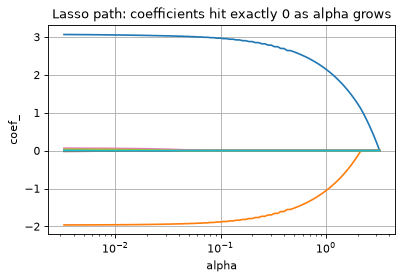

In [12]:
al, cf, _ = lm.lasso_path(X, y)
plt.semilogx(al, cf.T); plt.xlabel("alpha"); plt.ylabel("coef_")
plt.title("Lasso path: coefficients hit exactly 0 as alpha grows"); plt.show()

**確認**
真の非ゼロは最初の 2 特徴だけ。Ridge は全係数を小さくするが 0 にはしない。Lasso は不要な 8 個を**ぴったり 0** にした（代償として、有効な 2 番目の係数は Ridge で `-1.81`、Lasso で `-1.70` と、Lasso のほうが強く縮んだ）。

### 1.1.3.1 座標降下法と Gap Safe Screening
**原典**: 1 つの特徴 j だけを動かす 1 次元問題に分解して解く。解は soft-thresholding `S(z, α) = sign(z)·max(0, |z|−α)` を使い、`|z| ≤ α` なら **ちょうど 0**。特徴を巡回（`selection="cyclic"`）またはランダムに選び、双対ギャップが `tol` 未満になれば停止。Gap Safe Screening は「最適解で 0 になる特徴」を途中で安全に除外して高速化する。

In [13]:
h("1.1.3.1 soft-thresholding: 直交設計 (||x_j||^2 = n) なら w_j = S(x_j^T y / n, alpha)")
Xo = np.linalg.qr(rng.randn(200, 4))[0] * np.sqrt(200)  # 列が直交, ||x_j||^2 = n
yo = Xo @ [3, 1, 0.2, -0.05] + 0.01 * rng.randn(200)
alpha = 0.3
z = Xo.T @ yo / 200
manual = np.sign(z) * np.maximum(0, np.abs(z) - alpha)
# fit_intercept=False: 中心化すると列の直交性が崩れるため、定数項なしで比べる
lasso = lm.Lasso(alpha=alpha, fit_intercept=False, tol=1e-12).fit(Xo, yo).coef_
print("手計算:", manual, "\nLasso :", lasso)
assert np.allclose(manual, lasso, atol=1e-4)


=== 1.1.3.1 soft-thresholding: 直交設計 (||x_j||^2 = n) なら w_j = S(x_j^T y / n, alpha) ===


手計算: [ 2.7001  0.6999  0.     -0.    ] 
Lasso : [ 2.7001  0.6999  0.     -0.    ]


**確認**（列が直交、`‖x_j‖² = n`、定数項なしの設計）: 手計算 `w_j = S(x_jᵀy/n, α)` と `Lasso` の結果が一致した。
（最初は定数項ありで比べて食い違った。`fit_intercept=True` は X を中心化するため、直交だった列の直交性が崩れるのが原因。式が成り立つ前提条件を確かめられた。）

### 1.1.3.2 正則化パラメータの選び方
**原典**
- **CV**: `LassoCV` / `LassoLarsCV`。共線な特徴が多い高次元では `LassoCV` が無難。`LassoLarsCV` はより関連性の高い α を探索し、サンプル数が特徴数に比べて非常に少ないと `LassoCV` より速いことが多い。
- **情報量規準**: `LassoLarsIC`（AIC / BIC）。正則化パスを 1 回計算するだけで済み、k 分割 CV の k+1 回より安い。ただし学習データ上で計算する、漸近理論に基づく、自由度の推定が要る、条件が悪い（特徴 > サンプル）と壊れやすい、という注意点がある。
- **AIC / BIC の定義**: `AIC = −2 log L̂ + 2d`、BIC は `2` を `log N` に置換。`noise_variance` 未指定なら OLS の残差から不偏推定する（`n_samples > n_features` のときのみ有効）。
- **SVM の C との関係**: `alpha = 1/C` または `alpha = 1/(n_samples·C)`（推定器と目的関数による）。

In [14]:
h("1.1.3.2 LassoCV と LassoLarsIC (AIC/BIC)")
print("LassoCV alpha_ =", round(lm.LassoCV(cv=5).fit(X, y).alpha_, 4))
for crit in ["aic", "bic"]:
    ic = lm.LassoLarsIC(criterion=crit).fit(X, y)
    print(f"LassoLarsIC({crit}) alpha_ = {ic.alpha_:.4f}, 非ゼロ = {(ic.coef_ != 0).sum()}")


=== 1.1.3.2 LassoCV と LassoLarsIC (AIC/BIC) ===
LassoCV alpha_ = 0.04
LassoLarsIC(aic) alpha_ = 0.0463, 非ゼロ = 3
LassoLarsIC(bic) alpha_ = 0.0707, 非ゼロ = 2


**確認**（真の非ゼロ 2 個の合成データ）
BIC のほうが α が大きく（罰則が強く）、真の構造と同じ 2 個に絞れた。AIC は 1 個余計に残した。BIC は `log N` を使う分、サンプルが多いほど罰則が重い。

## 1.1.4 Multi-task Lasso

**原典**: `y` が `(n_samples, n_tasks)` の 2 次元のとき、複数の回帰を**同時に**スパース推定する。制約は「選ばれる特徴が全タスクで同じ」。混合 ℓ₁ℓ₂ ノルム `‖W‖₂₁` で正則化し、係数行列の非ゼロが**列（特徴）単位**でそろう。座標降下法で解く。

In [15]:
h("1.1.4 MultiTaskLasso: 全タスクで同じ特徴が選ばれる (非ゼロは列単位)")
W = np.zeros((8, 3)); W[[0, 3], :] = rng.randn(2, 3) * 3
X = rng.randn(80, 8); Y = X @ W + 0.1 * rng.randn(80, 3)
mt = lm.MultiTaskLasso(alpha=0.2).fit(X, Y)
print("MultiTaskLasso 非ゼロ行:", np.flatnonzero((mt.coef_ != 0).any(axis=0)),
      "| 行内で非ゼロが揃っているか:", ((mt.coef_ != 0).all(axis=0) | (mt.coef_ == 0).all(axis=0)).all())
sc = np.array([lm.Lasso(alpha=0.2).fit(X, Y[:, k]).coef_ != 0 for k in range(3)])
print("個別 Lasso の非ゼロ位置(タスクごと):\n", sc.astype(int))


=== 1.1.4 MultiTaskLasso: 全タスクで同じ特徴が選ばれる (非ゼロは列単位) ===
MultiTaskLasso 非ゼロ行: [0 3] | 行内で非ゼロが揃っているか: True
個別 Lasso の非ゼロ位置(タスクごと):
 [[1 0 0 1 0 0 0 0]
 [1 0 0 1 0 0 0 0]
 [1 0 0 1 0 0 0 0]]


**確認**: 8 特徴のうち特徴 0・3 だけが真に効くデータで `MultiTaskLasso` は非ゼロ位置 `[0 3]`、全タスクで同じ。個別の `Lasso` を各タスクに当てても今回は同じ位置になった。ガイドの図は「個別 Lasso は非ゼロが散らばる」と説明しているが、**信号が強い今回の設定ではその差を再現できなかった**（差が出る条件は未検証）。

## 1.1.5 Elastic-Net

**原典**: L1 と L2 の両方で正則化。`l1_ratio`（ρ）で混合比を決める。Lasso のスパース性と Ridge の安定性を両立する。**相関する特徴があると Lasso は片方をランダムに選びがちだが、Elastic-Net は両方を選びやすい**。目的関数 `1/(2n)‖Xw−y‖² + αρ‖w‖₁ + α(1−ρ)/2·‖w‖₂²`。`ElasticNetCV` で `alpha` と `l1_ratio` を CV 選択。

In [16]:
h("1.1.5 ElasticNet: 相関の強い特徴 -> Lasso は片方、ElasticNet は両方")
z = rng.randn(200)
X = np.c_[z + 0.01 * rng.randn(200), z + 0.01 * rng.randn(200), rng.randn(200)]
y = z * 2 + 0.1 * rng.randn(200)
print("Lasso      :", lm.Lasso(alpha=0.1).fit(X, y).coef_)
print("ElasticNet :", lm.ElasticNet(alpha=0.1, l1_ratio=0.3).fit(X, y).coef_)


=== 1.1.5 ElasticNet: 相関の強い特徴 -> Lasso は片方、ElasticNet は両方 ===
Lasso      : [1.9054 0.     0.    ]
ElasticNet : [0.9563 0.953  0.    ]


**確認**（特徴 0・1 がほぼ同一で、どちらも y に効く）
係数の合計はほぼ同じ（約 1.9）で、Lasso は 1 つに集中、Elastic-Net は均等に分担。

## 1.1.6 Multi-task Elastic-Net
**原典**: 1.1.4 の Elastic-Net 版。混合 ℓ₁ℓ₂ ノルムと ℓ₂ ノルムで正則化。`MultiTaskElasticNetCV` で `alpha` と `l1_ratio` を選ぶ。（コードでの確認は省略。）

## 1.1.7 Least Angle Regression（LARS）
**原典**: 高次元データ向けの回帰アルゴリズム。前進的段階回帰に似ており、各ステップで目的変数と最も相関する特徴を選ぶ。相関が同じ特徴が複数あるときは、同じ特徴を進み続けるのではなく、**それらの二等分方向**に進む。
- 利点: 特徴数がサンプル数より非常に多い場合に効率的 / 前進選択と同程度の速さで OLS と同じ計算量のオーダー / 区分線形の**解の全パス**が得られる（CV 等に便利） / 2 つの特徴の相関が同程度なら係数が同じ速さで増え、直感どおりで安定 / Lasso など他の推定器向けに変形しやすい。
- 欠点: 残差の反復的な再当てはめに基づくため、ノイズに特に敏感に見える（Efron ら 2004 の議論を参照）。
- 使い方: `Lars`、低レベルは `lars_path` / `lars_path_gram`。

## 1.1.8 LARS Lasso
**原典**: `LassoLars` は LARS で実装した Lasso。座標降下法と違い、**厳密解**（係数ノルムの区分線形関数）が得られる。全係数パスを「ほぼ無料で」得られるので、パス取得は `lars_path` / `lars_path_gram` でよく行う。全パスは `coef_path_`（形 `(n_features, max_features+1)`、1 列目は常に 0）。

In [17]:
h("1.1.8 LassoLars: ガイドの例と、係数パス (coef_path_)")
reg = lm.LassoLars(alpha=0.1).fit([[0, 0], [1, 1]], [0, 1])
print("coef_", reg.coef_)
assert np.allclose(reg.coef_, [0.6, 0.0])
X = rng.randn(100, 6); y = X[:, 0] * 3 + X[:, 2] * 1.5 + 0.1 * rng.randn(100)
path = lm.LassoLars(alpha=0.0).fit(X, y)
print("coef_path_ shape =", path.coef_path_.shape, "| 1列目は常に0:", (path.coef_path_[:, 0] == 0).all())


=== 1.1.8 LassoLars: ガイドの例と、係数パス (coef_path_) ===
coef_ [0.6 0. ]
coef_path_ shape = (6, 7) | 1列目は常に0: True


**確認**

## 1.1.9 Orthogonal Matching Pursuit（OMP）
**原典**: 非ゼロ係数の**個数**を制約（ℓ₀ 疑似ノルム）して当てはめを近似する。LARS と同じ前進的特徴選択で、指定個数の非ゼロを持つ解に近づける。代わりに誤差の許容値 `tol` を指定する形式もある。各ステップで残差と最も相関する「原子」を貪欲に追加し、**直交射影で残差を再計算**する点が単純な MP より良い。

In [18]:
h("1.1.9 OMP: 非ゼロ係数の個数を指定する (l0 制約)")
for k in [1, 2, 3]:
    c = lm.OrthogonalMatchingPursuit(n_nonzero_coefs=k).fit(X, y).coef_
    print(f"n_nonzero_coefs={k}: 非ゼロ位置 {np.flatnonzero(c)}")


=== 1.1.9 OMP: 非ゼロ係数の個数を指定する (l0 制約) ===
n_nonzero_coefs=1: 非ゼロ位置 [0]
n_nonzero_coefs=2: 非ゼロ位置 [0 2]
n_nonzero_coefs=3: 非ゼロ位置 [0 1 2]


**確認**（真の非ゼロは特徴 0 と 2）
効きの強い順（0 → 2 → …）に貪欲に選ばれ、個数を直接指定できる。

## 1.1.10 Bayesian Regression

**原典**: 正則化パラメータを固定せず、**データから推定**する（超パラメータに無情報事前分布を置く）。Ridge の ℓ₂ 正則化は係数に**ガウス事前分布**を置いた MAP 推定と等価。その精度 λ を手で決める代わりに確率変数として推定する。出力 `y` は `Xw` を中心とするガウス分布 `N(y | Xw, α⁻¹)` と仮定し、α もデータから推定する。
- 利点: データに適応する / 正則化パラメータを推定手順に組み込める。
- 欠点: 推論に時間がかかる。

### 1.1.10.1 Bayesian Ridge
**原典**: 係数の事前分布は球状ガウス `N(w | 0, λ⁻¹I)`。α, λ の事前分布は共役なガンマ分布。`w, α, λ` は学習中に同時推定され、α, λ は対数周辺尤度の最大化で決まる（Tipping 2001 の付録 A、更新は MacKay 1992）。初期値は `alpha_init` / `lambda_init`。ガンマ事前の 4 超パラメータ（α₁, α₂, λ₁, λ₂）は既定 `1e-6`（無情報）。OLS とは係数が僅かに異なるが、不良設定問題に頑健。

In [19]:
h("1.1.10.1 BayesianRidge: ガイドの例")
X = [[0.0, 0.0], [1.0, 1.0], [2.0, 2.0], [3.0, 3.0]]; Y = [0.0, 1.0, 2.0, 3.0]
br = lm.BayesianRidge().fit(X, Y)
print("predict([[1,0]]) =", br.predict([[1, 0.0]]), "coef_", br.coef_)
assert np.allclose(br.predict([[1, 0.0]]), [0.5], atol=1e-4)
print("学習された alpha_(ノイズ精度)=%.3g lambda_(重み精度)=%.3g" % (br.alpha_, br.lambda_))


=== 1.1.10.1 BayesianRidge: ガイドの例 ===
predict([[1,0]]) = [0.5] coef_ [0.5 0.5]
学習された alpha_(ノイズ精度)=1.5e+06 lambda_(重み精度)=2


**確認**
- `alpha_` が巨大 = 「ノイズはほぼ無い」とデータから判断（データは完全な直線）。**Ridge の α を手で選ぶ代わりに、自分で決めてくれた**ことが確認できる。

### 1.1.10.2 ARD（Automatic Relevance Determination）
**原典**: Bayesian Ridge に似るが、**係数ごとに別々の精度 λᵢ** を持つ楕円ガウス事前分布を使う。そのぶん**よりスパース**な係数になる（Sparse Bayesian Learning / Relevance Vector Machine とも呼ばれる）。

In [20]:
h("1.1.10.2 ARD は BayesianRidge よりスパース")
X = rng.randn(100, 10); y = X[:, 0] * 2 - X[:, 1] + 0.3 * rng.randn(100)
print("BayesianRidge:", lm.BayesianRidge().fit(X, y).coef_)
print("ARDRegression:", lm.ARDRegression().fit(X, y).coef_)


=== 1.1.10.2 ARD は BayesianRidge よりスパース ===
BayesianRidge: [ 1.9853 -1.0392 -0.0231 -0.0468  0.0046 -0.0263  0.0069  0.0124  0.0326
 -0.0135]
ARDRegression: [ 1.9843 -1.036   0.     -0.0387  0.      0.      0.      0.      0.0168
  0.    ]


**確認**（真の非ゼロ 2 個 / 特徴 10 個）
ARD は 10 個中 6 個が厳密に 0。Bayesian Ridge は全部が小さな非ゼロ。ただし ARD も完全に真の構造（2 個）には絞れていない。

## 1.1.11 Logistic regression（ロジスティック回帰）

**原典**: 名前に反して**分類**器（scikit-learn / ML の用語では回帰ではない）。ロジット回帰、MaxEnt、対数線形分類器とも呼ばれる。二値、One-vs-Rest、多項（multinomial）に対応し、ℓ₁ / ℓ₂ / Elastic-Net 正則化を付けられる。
- **正則化は既定で有効**（機械学習では普通だが統計学では普通でない）。数値安定性も上がる。無正則化は `C` を非常に大きくするのと同じ（`C=np.inf`）。
- GLM（二項/ベルヌーイ分布 + ロジットリンク）の特殊ケース。確率に閾値（既定 0.5）を当てて分類する。

### 1.1.11.1 二値
**原典**: `predict_proba` は `p̂(Xᵢ) = expit(Xᵢw + w₀) = 1/(1+exp(−Xᵢw − w₀))`。損失はサンプル重み `sᵢ` 付きの対数損失の**加重平均** + `r(w)/(S·C)`（`S = Σsᵢ`）。ペナルティ `r(w)`:

| 指定 | r(w) |
|---|---|
| なし (`C=np.inf`) | 0 |
| ℓ₁ (`l1_ratio=1`) | ‖w‖₁ |
| ℓ₂ (`l1_ratio=0`) | ½‖w‖₂² |
| ElasticNet (`0<l1_ratio<1`) | (1−ρ)/2·wᵀw + ρ‖w‖₁ |

クラス重み・サンプル重みのスケールは最適化問題に影響する。例: サンプル重みを b 倍にすると、（逆）正則化強度 C を b 倍にするのと等価。

In [21]:
h("1.1.11.1 二値ロジスティック回帰: predict_proba = expit(Xw + w0)")
from sklearn.datasets import load_iris, make_classification
Xb, yb = make_classification(n_samples=200, n_features=5, random_state=0)
lr = lm.LogisticRegression().fit(Xb, yb)
manual = expit(Xb @ lr.coef_[0] + lr.intercept_[0])
print("式と一致:", np.allclose(manual, lr.predict_proba(Xb)[:, 1]),
      "| 閾値0.5で predict と一致:", ((manual > 0.5).astype(int) == lr.predict(Xb)).all())


=== 1.1.11.1 二値ロジスティック回帰: predict_proba = expit(Xw + w0) ===
式と一致: True | 閾値0.5で predict と一致: True


In [22]:
h("1.1.11.1 正則化は既定で有効。C を大きくすると無正則化に近づく")
for C in [0.01, 1, 1e6, np.inf]:
    print(f"C={C:<8} ||w|| = {np.linalg.norm(lm.LogisticRegression(C=C, max_iter=5000).fit(Xb, yb).coef_):.3f}")


=== 1.1.11.1 正則化は既定で有効。C を大きくすると無正則化に近づく ===
C=0.01     ||w|| = 0.634
C=1        ||w|| = 3.045
C=1000000.0 ||w|| = 4.121
C=inf      ||w|| = 4.121


In [23]:
h("1.1.11.1 サンプル重みを b 倍 == C を b 倍 (目的関数が S で正規化されるため)")
sw = rng.rand(len(yb)) + 0.5
a = lm.LogisticRegression(C=1.0, tol=1e-10, max_iter=5000).fit(Xb, yb, sample_weight=sw * 5).coef_
b = lm.LogisticRegression(C=5.0, tol=1e-10, max_iter=5000).fit(Xb, yb, sample_weight=sw).coef_
print("一致:", np.allclose(a, b, atol=1e-4), "\nsw*5 & C=1:", a[0][:3], "\nsw & C=5  :", b[0][:3])


=== 1.1.11.1 サンプル重みを b 倍 == C を b 倍 (目的関数が S で正規化されるため) ===
一致: True 
sw*5 & C=1: [-1.2772 -0.3941 -1.8255] 
sw & C=5  : [-1.2772 -0.3941 -1.8255]


**確認**
- `predict_proba` は `expit(Xw + w0)` と一致し、閾値 0.5 の判定は `predict` と一致した。
- `C` を上げると係数ノルムが増える（正則化が弱まる）:
- **サンプル重み ×5 かつ C=1 と、重みそのままで C=5 は係数が一致**した（`[-1.2772 -0.3941 -1.8255 …]`）。目的関数が `S` で正規化されているため。
- **発見（API の変化）**: このバージョンのガイドは、ペナルティの指定を `penalty=` ではなく `C` と `l1_ratio` で説明している（表の「none (C=np.inf)」「ℓ₁ (l1_ratio=1)」）。実際に `l1_ratio=0/1/0.5`, `C=np.inf` の組で指定して動いた。

### 1.1.11.2 多項（multinomial）
**原典**: K クラスへの拡張。係数は行列 `W`（行がクラス）。`p̂ₖ = exp(XᵢWₖ + W₀ₖ) / Σₗ exp(XᵢWₗ + W₀ₗ)`（softmax）。K−1 本の重みでも表せるが、**あえて K 本で過剰パラメータ化**している（実装の容易さと、クラス順序に対する対称な帰納バイアスのため）。正則化があるときは特に重要。無正則化だと解が一意でなくなりうる。

In [24]:
h("1.1.11.2 多クラス: 全クラス K 本の重みを持つ (過剰パラメータ化) / softmax")
Xi, yi = load_iris(return_X_y=True)
mn = lm.LogisticRegression(max_iter=1000).fit(Xi, yi)
print("coef_ shape =", mn.coef_.shape, "(K=3 本)")
s = np.exp(Xi @ mn.coef_.T + mn.intercept_); s /= s.sum(axis=1, keepdims=True)
print("softmax 手計算と一致:", np.allclose(s, mn.predict_proba(Xi)))


=== 1.1.11.2 多クラス: 全クラス K 本の重みを持つ (過剰パラメータ化) / softmax ===
coef_ shape = (3, 4) (K=3 本)
softmax 手計算と一致: True


**確認**: iris で `coef_.shape = (3, 4)`（3 クラス × 4 特徴 = K 本）、softmax の手計算が `predict_proba` と一致。

### 1.1.11.3 ソルバ
**原典**: `lbfgs`（既定）, `liblinear`, `newton-cg`, `newton-cholesky`, `sag`, `saga`。使い分けの目安:
- 既定は堅牢な `lbfgs`。
- `n_samples >> n_features` なら `newton-cholesky`（高精度＝小さい `tol` にも到達）。
- 大規模データなら `saga`（特に低精度＝大きい `tol`）。さらに大きければ `SGDClassifier(loss="log_loss")` も検討（速いがチューニングが要る）。

In [25]:
h("1.1.11.3 ソルバごとの対応ペナルティ (表の検証)")
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings("ignore", category=ConvergenceWarning)
Xs = (Xb - Xb.mean(0)) / Xb.std(0)
for solver in ["lbfgs", "liblinear", "newton-cg", "newton-cholesky", "sag", "saga"]:
    row = []
    for label, kw in [("L2", dict(l1_ratio=0.0)), ("L1", dict(l1_ratio=1.0)),
                      ("EN", dict(l1_ratio=0.5)), ("none", dict(C=np.inf))]:
        try:
            lm.LogisticRegression(solver=solver, max_iter=300, **kw).fit(Xs, yb)
            row.append(f"{label}:yes")
        except Exception as e:
            row.append(f"{label}:no ")
    print(f"{solver:16}", " ".join(row))
print("多クラス(iris)を liblinear で:", end=" ")
try:
    lm.LogisticRegression(solver="liblinear").fit(Xi, yi); print("fit できた")
except Exception as e:
    print(type(e).__name__, str(e)[:80])


=== 1.1.11.3 ソルバごとの対応ペナルティ (表の検証) ===
lbfgs            L2:yes L1:no  EN:no  none:yes
liblinear        L2:yes L1:yes EN:no  none:no 


newton-cg        L2:yes L1:no  EN:no  none:yes
newton-cholesky  L2:yes L1:no  EN:no  none:yes


sag              L2:yes L1:no  EN:no  none:yes
saga             L2:yes L1:yes EN:yes none:yes
多クラス(iris)を liblinear で: ValueError The 'liblinear' solver does not support multiclass classification (n_classes >= 


/home/user/sandbox/study-sklearn/.venv/lib/python3.11/site-packages/sklearn/linear_model/_glm/_newton_solver.py:597: LinAlgWarning: The inner solver of NewtonCholeskySolver stumbled upon a singular or very ill-conditioned Hessian matrix at iteration 1. It will now resort to lbfgs instead.
Further options are to use another solver or to avoid such situation in the first place. Possible remedies are removing collinear features of X or increasing the penalization strengths.
The original Linear Algebra message was:
An ill-conditioned matrix detected: slice 0 has rcond = 3.3155936448032465e-18.
  warnings.warn(


**確認（表の検証）**: 6 つのソルバ × 4 つのペナルティを実際に `fit` して、ガイドの表と一致するか見た。

**発見**: このデータ（`make_classification`）は冗長な特徴を含み、5 特徴の行列ランクは 3 しかない。上のセルの stderr に出ている `LinAlgWarning`（ヘッセ行列が特異）は、**無正則化（`C=np.inf`）の `newton-cholesky` のときだけ**出た（L2 では警告なし。別実行で確認）。警告どおり `lbfgs` に切り替えて完走している。ヘッセ行列を陽に解くソルバは、共線性があり正則化もないと不安定になる。

ガイドの表と**完全に一致**。iris（3 クラス）を `liblinear` で `fit` すると `ValueError: The 'liblinear' solver does not support multiclass classification` になる（多項非対応の表どおり）。

**原典（ソルバの詳細）の要点**
- `liblinear`: 座標降下法で、真の多項モデルは学習できない。多クラスは `OneVsRestClassifier(LogisticRegression(solver="liblinear"))` で。多項損失のほうが One-vs-Rest より**較正が良い**傾向。ℓ₁ 正則化で全係数が 0 にならない C の下限は `sklearn.svm.l1_min_c` で計算できる。**切片もペナルティ対象になる**（表の "Penalize the intercept (bad)"）。
- `lbfgs`/`newton-cg`/`newton-cholesky`/`sag` は ℓ₂ か無正則化のみ。これらと `saga` は真の多項モデルを学習する。
- `sag`: 確率的平均勾配法。サンプル数・特徴数ともに大きいとき速い。**スケールしていないデータに弱い**。
- `saga`: `sag` の派生で ℓ₁ も扱える。スパースな多項ロジスティックの第一候補で、**Elastic-Net を扱える唯一のソルバ**。
- `lbfgs`: BFGS の近似（準ニュートン法）。幅広いデータに対応するので既定。ただしスケールが揃っていないデータや、稀なカテゴリを one-hot にした特徴では性能が落ちる。
- `newton-cholesky`: ヘッセ行列を計算する厳密ニュートン法。`n_samples >> n_features` に最適だが、ℓ₂ のみで、メモリが `n_features` と `n_classes` の二乗に依存する。
- 差異の注意: `fit_intercept=False` で決定関数が 0 のサンプルがあると、`LogisticRegression(liblinear)` / `LinearSVC` は負クラスを予測するが、外部の liblinear は正クラスを予測する。そんなモデルは適合不足の可能性が高く、`fit_intercept=True` にして `intercept_scaling` を上げるのが推奨。

**補足（原典のノート）**
- ℓ₁ 付きは疎なモデルになり、特徴選択に使える（L1-based feature selection）。
- 無正則化の回帰なら p 値・信頼区間が得られる（`statsmodels` が対応。sklearn 内ではブートストラップで代用）。
- `LogisticRegressionCV` は `C` と `l1_ratio` を組み込み CV で選ぶ。`newton-cg`, `sag`, `saga`, `lbfgs` は**ウォームスタート**のおかげで高次元・密データで速い。

## 1.1.12 Generalized Linear Models（GLM）

**原典**: 線形モデルを 2 点で拡張する。
1. 予測値を、線形結合 `Xw` に**逆リンク関数** `h` を通して結ぶ: `ŷ = h(Xw)`。
2. 二乗損失を、指数型分布族（正確には再生型 EDM）の**単位逸脱度** `d` に置き換える: `min 1/(2n)·Σ d(yᵢ, ŷᵢ) + α/2·‖w‖₂²`（サンプル重みがあれば加重平均）。

| 分布 | 目的変数の定義域 | 単位逸脱度 d(y, ŷ) |
|---|---|---|
| Normal | (−∞, ∞) | (y−ŷ)² |
| Bernoulli | {0, 1} | 2(y·log(y/ŷ) + (1−y)·log((1−y)/(1−ŷ))) |
| Categorical | {0, …, k} | 2Σ I(y=i)·yᵢ·log(I(y=i)/Î(y=i)) |
| Poisson | [0, ∞) | 2(y·log(y/ŷ) − y + ŷ) |
| Gamma | (0, ∞) | 2(log(ŷ/y) + y/ŷ − 1) |
| Inverse Gaussian | (0, ∞) | (y−ŷ)² / (y·ŷ²) |

**分布の選び方（原典）**
- 目的変数が**カウント**（非負整数）または相対頻度（非負）→ Poisson + log リンク。
- **正で歪んだ**値 → Gamma + log リンク。
- Gamma よりさらに裾が重い → Inverse Gaussian（または Tweedie 族のより高い分散冪）。
- 目的変数が**確率** → Bernoulli。ロジットリンクの Bernoulli は二値分類、softmax リンクの Categorical は多クラス分類。

**ユースケース例（原典）**: 年間降雨回数（Poisson）と 1 回の降雨量（Gamma）と年間降水量（Tweedie / 複合ポアソン・ガンマ）、保険料率（請求件数=Poisson、1 件のコスト=Gamma、年間総コスト=Tweedie）、債務不履行と不正検知（Bernoulli）、予知保全（停止回数=Poisson、停止時間=Gamma）、治験（Bernoulli）、ニュース分類（Categorical）。

### 1.1.12.1 使い方
**原典**: `TweedieRegressor` が Tweedie 分布の GLM。`power` で分布を選ぶ: `0`=Normal（この場合は `Ridge` や `ElasticNet` のほうが適切）、`1`=Poisson（`PoissonRegressor` は `TweedieRegressor(power=1, link='log')` と厳密に等価）、`2`=Gamma（`GammaRegressor` も同様）、`3`=Inverse Gaussian。リンク関数は `link` で指定。

**実用上の注意（原典）**
- X は**標準化**してから `fit`（ペナルティが特徴を平等に扱うように）。
- 線形予測子 `Xw` は負になりうるが Poisson/Gamma/Inverse Gaussian は負を許さないので、非負を保証する逆リンクが必要（`link='log'` なら `h(Xw) = exp(Xw)`）。
- **相対頻度**（`count / exposure`）は、`y = count/exposure`、`sample_weight = exposure` として Poisson で扱う。
- `power` を CV で選ぶときは**明示的な `scoring` を指定**（既定の `score` 自体が `power` の関数だから）。

In [26]:
h("1.1.12.1 TweedieRegressor: ガイドの例と、Poisson との同値性")
tw = lm.TweedieRegressor(power=1, alpha=0.5, link="log").fit([[0, 0], [0, 1], [2, 2]], [0, 1, 2])
print("coef_", tw.coef_, "intercept_", tw.intercept_)
assert np.allclose(tw.coef_, [0.2463, 0.4337], atol=1e-4)
po = lm.PoissonRegressor(alpha=0.5).fit([[0, 0], [0, 1], [2, 2]], [0, 1, 2])
print("PoissonRegressor と一致:", np.allclose(po.coef_, tw.coef_))


=== 1.1.12.1 TweedieRegressor: ガイドの例と、Poisson との同値性 ===


coef_ [0.2463 0.4337] intercept_ -0.7638091359123443


PoissonRegressor と一致: True


In [27]:
h("1.1.12.1 exposure: 頻度 = counts/exposure を y に、exposure を sample_weight に")
X = rng.randn(500, 1); exposure = rng.uniform(0.2, 2.0, 500)
counts = rng.poisson(exposure * np.exp(0.5 + 0.8 * X[:, 0]))
pr = lm.PoissonRegressor(alpha=1e-8).fit(X, counts / exposure, sample_weight=exposure)
print("真値 (0.5, 0.8) に対し intercept=%.3f coef=%.3f" % (pr.intercept_, pr.coef_[0]))


=== 1.1.12.1 exposure: 頻度 = counts/exposure を y に、exposure を sample_weight に ===


真値 (0.5, 0.8) に対し intercept=0.468 coef=0.807

**確認**
exposure の実験: 真の切片 0.5・傾き 0.8 で生成したカウントに対し、`y=counts/exposure`, `sample_weight=exposure` で推定 → `intercept=0.468, coef=0.807`。**ほぼ回復できた**。

## 1.1.13 Stochastic Gradient Descent（SGD）

**原典**: 線形モデルを当てはめる単純かつ非常に効率的な方法。サンプル数（と特徴数）が非常に大きいときに有効。`partial_fit` で**オンライン / out-of-core 学習**ができる。`SGDClassifier` / `SGDRegressor` は様々な（凸）損失関数とペナルティに対応。`loss="log_loss"` ならロジスティック回帰、`loss="hinge"` なら線形 SVM。詳細は専用の SGD の節（1.5）。

In [28]:
h("1.1.13 SGD: loss='log_loss' はロジスティック回帰、Perceptron は SGD のラッパー")
from sklearn.linear_model import SGDClassifier, Perceptron
Xs2 = (Xb - Xb.mean(0)) / Xb.std(0)
print("SGD(log_loss) 精度 %.3f / LogisticRegression 精度 %.3f" % (
    SGDClassifier(loss="log_loss", random_state=0).fit(Xs2, yb).score(Xs2, yb),
    lm.LogisticRegression().fit(Xs2, yb).score(Xs2, yb)))
p = Perceptron(random_state=0, shuffle=False).fit(Xs2, yb)
s = SGDClassifier(loss="perceptron", learning_rate="constant", eta0=1, penalty=None,
                  random_state=0, shuffle=False).fit(Xs2, yb)
print("Perceptron と SGD(loss=perceptron, 定数学習率) の係数一致:", np.allclose(p.coef_, s.coef_))
sgd = SGDClassifier(random_state=0)
for i in range(3):  # partial_fit: オンライン/out-of-core 学習
    sgd.partial_fit(Xs2[i::3], yb[i::3], classes=[0, 1])
print("partial_fit 3回後の精度 %.3f" % sgd.score(Xs2, yb))


=== 1.1.13 SGD: loss='log_loss' はロジスティック回帰、Perceptron は SGD のラッパー ===
SGD(log_loss) 精度 0.905 / LogisticRegression 精度 0.950
Perceptron と SGD(loss=perceptron, 定数学習率) の係数一致: True
partial_fit 3回後の精度 0.930


**確認**（標準化データ）
同じモデル族でも、SGD は**既定のままだと厳密解より精度が少し低い**（チューニングが要るという原典の注意どおり）。`partial_fit` の最初の呼び出しでは `classes=[0, 1]` を渡した。

### 1.1.13.1 Perceptron
**原典**: 大規模学習向けの単純な分類アルゴリズムで SGD から派生。既定では、学習率不要 / 正則化なし / **間違えたときだけ**更新。そのためヒンジ損失の SGD よりやや速く、得られるモデルもより疎になる。実体は `SGDClassifier` に perceptron 損失と定数学習率を指定したラッパー。

**確認**: `Perceptron` と `SGDClassifier(loss="perceptron", learning_rate="constant", eta0=1, penalty=None)` の係数が**完全一致**した（`shuffle=False`, 同じ `random_state`）。

### 1.1.13.2 Passive Aggressive
**原典**: 大規模オンライン学習向けの 2 種のアルゴリズム（PA-I, PA-II）。Perceptron 同様に学習率が不要だが、正則化パラメータ `eta0`（論文の C）を持つ。分類は `SGDClassifier(loss="hinge", penalty=None, learning_rate="pa1", eta0=1.0)`（PA-II は `"pa2"`）、回帰は `SGDRegressor(loss="epsilon_insensitive", penalty=None, learning_rate="pa1", eta0=1.0)`。（コードでの確認は省略。）

## 1.1.14 ロバスト回帰: 外れ値とモデル誤差

**原典**: 壊れたデータ（外れ値、またはモデルの誤り）があっても当てはめる。

In [29]:
h("1.1.14 ロバスト回帰: y 方向の外れ値 (真の傾き 2.0)")
x = rng.uniform(-3, 3, 100); yy = 2 * x + 1 + 0.3 * rng.randn(100)
yy[:15] += rng.uniform(15, 30, 15)  # 15% を大きな外れ値に
Xr = x[:, None]
models = {
    "OLS": lm.LinearRegression(),
    "Huber": lm.HuberRegressor(),
    "RANSAC": lm.RANSACRegressor(random_state=0),
    "TheilSen": lm.TheilSenRegressor(random_state=0),
}
for name, m in models.items():
    m.fit(Xr, yy)
    est = m.estimator_.coef_[0] if name == "RANSAC" else m.coef_[0]
    print(f"{name:9} 傾き = {est:.3f}")
print("RANSAC inlier 数:", int(models["RANSAC"].inlier_mask_.sum()), "/ 100 (外れ値 15 を除外できたか)")
print("Huber の外れ値判定 outliers_ 数:", int(models["Huber"].outliers_.sum()))


=== 1.1.14 ロバスト回帰: y 方向の外れ値 (真の傾き 2.0) ===
OLS       傾き = 1.450
Huber     傾き = 1.962
RANSAC    傾き = 1.969


TheilSen  傾き = 1.959
RANSAC inlier 数: 85 / 100 (外れ値 15 を除外できたか)
Huber の外れ値判定 outliers_ 数: 36


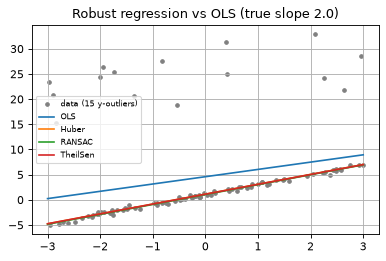

In [30]:
xs = np.linspace(-3, 3, 50)[:, None]
plt.scatter(Xr, yy, s=10, c="gray", label="data (15 y-outliers)")
for name, m in models.items():
    plt.plot(xs, m.predict(xs), label=name)
plt.legend(fontsize=7); plt.title("Robust regression vs OLS (true slope 2.0)"); plt.show()

### 1.1.14.1 場面と概念
- 外れ値は **X 方向**か **y 方向**か。
- 外れ値の**割合**と**大きさ**（小さい外れ値 / 大きい外れ値）。
- **破綻点（breakdown point）**: 当てはめが内側のデータを外し始めるまでに許容できる外れ値の割合。
- 高次元（特徴数が多い）でのロバスト当てはめは一般に非常に難しい。ここのモデルはその設定ではおそらく機能しない。

**推定器の選び方（原典）**: sklearn は 3 つ — `RANSAC`, `TheilSen`, `HuberRegressor`。
- `HuberRegressor` は `n_samples >> n_features` でない限り `RANSAC` / `TheilSen` より速いはず（この 2 つは部分集合で当てはめるため）。ただし既定パラメータでは `RANSAC` / `TheilSen` は `HuberRegressor` ほど頑健にはなりにくい。
- `RANSAC` は `TheilSen` より速く、サンプル数への伸びも良い。**y 方向の大きな外れ値**（最も一般的）に強い。
- `TheilSen` は **X 方向の中程度の外れ値**に強いが、高次元では失われる。
- **迷ったら `RANSAC`**。

**確認**（真の傾き 2.0、100 点のうち 15 点の y に +15〜+30 の大きな外れ値）
3 手法とも真値 2.0 にほぼ戻った。RANSAC は外れ値を**ちょうど 15 点除外**した。

### 1.1.14.2 RANSAC
**原典**: 完全データから**内点（inlier）のランダム部分集合**でモデルを当てはめる。非決定的で、妥当な結果になる確率は反復回数 `max_trials` に依存。各反復:
1. `min_samples` 個をランダムに選び、有効か確認（`is_data_valid`）。
2. その部分集合でモデルを当てはめ、有効か確認（`is_model_valid`）。
3. 全データの残差 `|estimator.predict(X) − y|` を計算し、`residual_threshold` 以下を内点とする。
4. 内点数が最大なら最良モデルとして保存（同数ならスコアの良いほう）。

`max_trials` 回、または停止条件（`stop_n_inliers`, `stop_score`）まで反復し、最終モデルは最良モデルの**全内点（consensus set）**で推定する。`is_data_valid` は当てはめ前に呼ばれるので、縮退した組み合わせの除外には計算効率が良い。

### 1.1.14.3 Theil-Sen
**原典**: 中央値を多次元へ一般化した推定量を使い、多変量の外れ値に頑健。ただし頑健性は**次元が上がると急速に低下**し、高次元では OLS と変わらなくなる。ノンパラメトリック（データ分布の仮定なし）。単変量の単回帰では**破綻点は約 29.3%**。計算量は `C(n_samples, n_subsamples)` のオーダーなので、部分母集団のサイズで制限する。

### 1.1.14.4 Huber 回帰
**原典**: `epsilon` を超える誤差のサンプル（外れ値扱い）には**線形損失**を適用する。Ridge と違う。`TheilSen` / `RANSAC` と違い、外れ値の影響を**無視せず、小さい重みを与える**。`epsilon = 1.35` で 95% の統計的効率が得られる。`SGDRegressor(loss="huber")` との違い: `HuberRegressor` は**スケール不変**（X, y のスケールを変えても頑健性が同じ）、少サンプルでも効率的。

**確認**
- **発見**: 上の実験（本物の外れ値 15 点）で、`HuberRegressor.outliers_` が真と判定した点は **36 点**。本物の外れ値より多い。`epsilon=1.35` の境界の外にある点を「外れ値扱い（線形損失）」にするだけで、**真の外れ値を検出する機能ではない**ことが分かる。外れ値検出には RANSAC の `inlier_mask_` のほうが向く。

## 1.1.15 Quantile Regression（分位点回帰）

**原典**: OLS が条件付き**平均**を推定するのに対し、条件付き**中央値**や他の分位点を推定する。点予測ではなく**区間**を予測したいときに有用。正規分布・分散一定の仮定に基づく予測区間と違い、分散が一定でない（が予測可能な）誤差や非正規誤差でも妥当な予測区間が得られる。**ピンボール損失**の最小化に基づき、線形以外のモデルでも条件付き分位点は推定できる（例: `GradientBoostingRegressor(loss="quantile", alpha=分位点)`）。実装は線形計画（`scipy.optimize.linprog`）。

損失: `PB_q(t) = q·max(t,0) + (1−q)·max(−t,0)`。目的関数 `1/n·Σ PB_q(yᵢ − Xᵢw) + α‖w‖₁`。ピンボール損失は残差に対して線形なので、二乗誤差ベースの平均推定より外れ値に**はるかに頑健**（その中間が `HuberRegressor`）。

In [31]:
h("1.1.15 QuantileRegressor: 分位点 q を下回る割合 ≈ q (ノイズが不均一でも)")
x = rng.uniform(0, 10, 400); yq = 2 * x + rng.randn(400) * (0.2 + 0.4 * x)  # 分散が x に比例
Xq = x[:, None]
for q in [0.1, 0.5, 0.9]:
    m = lm.QuantileRegressor(quantile=q, alpha=0, solver="highs").fit(Xq, yq)
    print(f"q={q}: 下回る割合 = {(yq < m.predict(Xq)).mean():.3f}  傾き = {m.coef_[0]:.3f}")


=== 1.1.15 QuantileRegressor: 分位点 q を下回る割合 ≈ q (ノイズが不均一でも) ===


q=0.1: 下回る割合 = 0.100  傾き = 1.443
q=0.5: 下回る割合 = 0.497  傾き = 1.930
q=0.9: 下回る割合 = 0.900  傾き = 2.454


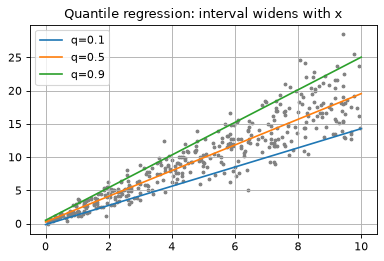

In [32]:
xs = np.linspace(0, 10, 50)[:, None]
plt.scatter(Xq, yq, s=6, c="gray")
for q in [0.1, 0.5, 0.9]:
    plt.plot(xs, lm.QuantileRegressor(quantile=q, alpha=0, solver="highs").fit(Xq, yq).predict(xs), label=f"q={q}")
plt.legend(); plt.title("Quantile regression: interval widens with x"); plt.show()

**確認**（分散が x に比例して増える不均一データ、400 点）
- 各分位点 q について、「予測を下回る観測の割合 ≈ q」が成り立った（0.100 / 0.497 / 0.900）。
- 分散が x とともに広がるため、上位の分位点ほど**傾きが大きい**（1.44 → 1.93 → 2.45）。**予測区間の幅が x とともに広がる**ことを、モデルが表現できている。OLS の区間（幅が一定）では表せない。

## 1.1.16 多項式回帰: 基底関数による線形モデルの拡張

**原典**: 非線形関数に変換した特徴で線形モデルを学習するのは、機械学習で一般的なパターン。線形手法の高速さを保ちつつ、はるかに広範なデータに当てはめられる。例えば 2 次元の平面 `w₀ + w₁x₁ + w₂x₂` を、2 次の多項式特徴で放物面 `w₀ + w₁x₁ + w₂x₂ + w₃x₁x₂ + w₄x₁² + w₅x₂²` に拡張できる。**`w` について線形のままなので、同じ手法で解ける**（意外な観察）。

`PolynomialFeatures` が特徴行列を指定次数へ変換し、`Pipeline` と組み合わせれば 1 つのオブジェクトにできる。`interaction_only=True` にすると、同じ特徴の冪（`xᵢⁿ`）を除き、**異なる特徴どうしの積（交互作用）**だけが得られる。ブール特徴では `xᵢⁿ = xᵢ` で冪は無意味だが、`xᵢxⱼ` は 2 つの論理積を表す。これで **XOR 問題を線形分類器で解ける**。

In [33]:
h("1.1.16 PolynomialFeatures: ガイドの例")
print(PolynomialFeatures(degree=2).fit_transform(np.arange(6).reshape(3, 2)))
x = np.arange(5); y = 3 - 2 * x + x ** 2 - x ** 3
model = Pipeline([("poly", PolynomialFeatures(degree=3)),
                  ("linear", lm.LinearRegression(fit_intercept=False))]).fit(x[:, None], y)
print("回復した係数:", model.named_steps["linear"].coef_)
assert np.allclose(model.named_steps["linear"].coef_, [3, -2, 1, -1])


=== 1.1.16 PolynomialFeatures: ガイドの例 ===
[[ 1.  0.  1.  0.  0.  1.]
 [ 1.  2.  3.  4.  6.  9.]
 [ 1.  4.  5. 16. 20. 25.]]
回復した係数: [ 3. -2.  1. -1.]


In [34]:
h("1.1.16 interaction_only=True で XOR が線形分類器 (Perceptron) で解ける")
X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]]); y = X[:, 0] ^ X[:, 1]
print("そのまま      の精度:", Perceptron(max_iter=10, tol=None, shuffle=False).fit(X, y).score(X, y))
Xi2 = PolynomialFeatures(interaction_only=True).fit_transform(X).astype(int)
clf = Perceptron(fit_intercept=False, max_iter=10, tol=None, shuffle=False).fit(Xi2, y)
print("交互作用項つき の精度:", clf.score(Xi2, y))
assert clf.score(Xi2, y) == 1.0
print("\nOK: すべての assert を通過")


=== 1.1.16 interaction_only=True で XOR が線形分類器 (Perceptron) で解ける ===
そのまま      の精度: 0.5
交互作用項つき の精度: 1.0

OK: すべての assert を通過


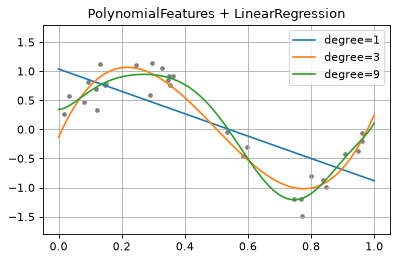

In [35]:
xx = np.sort(rng.uniform(0, 1, 30)); yt = np.sin(2 * np.pi * xx) + 0.2 * rng.randn(30)
xg = np.linspace(0, 1, 100)[:, None]
plt.scatter(xx, yt, s=10, c="gray")
for d in [1, 3, 9]:
    mdl = Pipeline([("poly", PolynomialFeatures(degree=d)), ("lin", lm.LinearRegression())]).fit(xx[:, None], yt)
    plt.plot(xg, mdl.predict(xg), label=f"degree={d}")
plt.ylim(-1.8, 1.8); plt.legend(); plt.title("PolynomialFeatures + LinearRegression"); plt.show()

**確認**

## この節から得た「型」の整理（ドメインモデル視点）

- **すべての推定器が同じ契約に従う**: 1.1 で登場した多数のクラスは、`fit(X, y)` → `coef_` / `intercept_` の共通の形。`Ridge` を `Lasso` や `ElasticNet` に**差し替えても呼び出し側は変わらない**（USB のようなもの）。
- **例外は静かに存在する**: 二値の `RidgeClassifier.coef_` の形が `(2,)` で `LogisticRegression` の `(1, 2)` と違うなど、契約の細部は揃っていない。差し替えは**型は同じでも形が違う**ことがある。
- **「CV 付き」は別クラス**: `RidgeCV`, `LassoCV`, `ElasticNetCV`, `LogisticRegressionCV` — ハイパーパラメータ探索を内包した Estimator（メタ推定器の軽量版）。一般形は 3.2 節の `GridSearchCV`。
- **前処理と合成する**: 1.1.16 の `Pipeline([PolynomialFeatures, LinearRegression])` が、「Transformer + Predictor を直列合成した**もの自体が Estimator**」という設計（`domain-model.md` の Composite）を実例で示している。

## 実験で分かった注意点（まとめ）
1. 共線性が強いと OLS の係数の標準偏差が数百倍になる（1.1.1）。
2. `RidgeClassifier` の二値 `coef_` は `(2,)`、`LogisticRegression` は `(1, 2)`（1.1.2）。
3. `fit_intercept=True` だと X が中心化されるので、直交性を前提とする手計算とは一致しない（1.1.3.1）。
4. `LassoLarsIC` の BIC は AIC より罰則が重く、真の構造に近い（1.1.3.2）。
5. `HuberRegressor.outliers_` は本物の外れ値検出器ではない（1.1.14）。
6. `SGDClassifier` は既定のままだと厳密解より精度が落ちやすい（1.1.13）。